# Матрично-векторное дифференцирование. Практика

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

В большинстве практических задач оптимизации оказывается невозможным получить аналитические выражения для градиентов. Это связано с тем, что их целевые функции имеют сложную структуру. В таких случаях прибегают к численным методам дифференцирования. Существует множество подходов, имеющих различные реализации. В рамках этого семинара мы поговорим про приближение производных конечными разностями и про библиотеки
1. [Autograd](#Autograd)
2. [Jax](#JAX)
3. [Pytorch](#PyTorch)

## Конечные разности

Один из самых простых способов вычисления частных производных — приближение конечными разностями. Вместо перехода к пределу:

$$
\frac{\partial f(\dots, x_k, \dots)}{\partial x_k} = \lim_{\Delta x_k \to 0} \frac{f(\dots, x_k + \Delta x_k, \dots) - f(\dots, x_k, \dots)}{\Delta x_k}
$$

предлагается использовать достаточно малое $\varepsilon = \Delta x_k$:

$$
\frac{\partial f}{\partial x_k} \approx \frac{f(\dots, x_k + \varepsilon, \dots) - f(\dots, x_k - \varepsilon, \dots)}{2\varepsilon}.
$$

Напишем код для подсчета производных целевых функций из примера:

In [2]:
def dfdx_i(f: callable, x: np.ndarray, i=0, eps=1e-3):
    step_x = np.zeros_like(x)
    step_x[i] = eps
    return (f(x + step_x) - f(x - step_x)) / (2 * eps)

Рассмотрим функцию $f: \mathbb{R}^2 \to \mathbb{R}$:

$$
f(x, y) = \sin \left(x^2\right)e^{-\frac{x^2 + y^2}{5}}
$$

In [3]:
def f(x: np.ndarray):
    return np.sin(x[0]**2) * np.exp(-x.T @ x/5)

Для этой функции известно аналитическое выражение градиента, напишем для него код:

In [4]:
def true_grad_f(x: np.ndarray):
    return np.array([(2*x[0]*np.cos(x[0]**2) - 0.4*x[0]*np.sin(x[0]**2)) * np.exp(-x.T @ x / 5),
                     -0.4 * x[1] * np.sin(x[0]**2) * np.exp(-x.T @ x / 5)
                    ])

Варьируя $\varepsilon$, вычислим зависимость ошибки аппроксимации в точке (5.0, 2.0) от величины шага.

In [5]:
grad_norms = []

point = np.array([5, 2.])
eps_range = np.logspace(-8, -1, 100000)
for eps in eps_range:
    grad_norms.append(
        np.linalg.norm(np.array([dfdx_i(f, point, i, eps=eps) for i in [0, 1]]) - true_grad_f(point))
    )

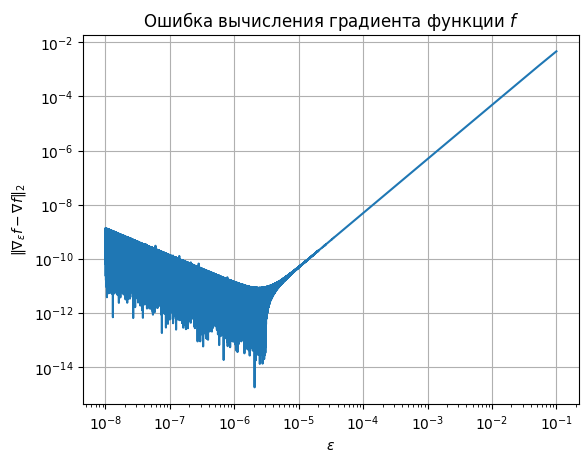

In [6]:
plt.loglog(eps_range, grad_norms)
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$\|\nabla_{\varepsilon}f - \nabla f\|_2$")
plt.title(r"Ошибка вычисления градиента функции $f$")
plt.grid()
plt.show()

Попробуем проанализировать такое поведение ошибки для $\| h \|_2 = 1$. Рассмотрим разложение функции:

$$
f(x + \varepsilon h) = f(x) + \langle \nabla f(x), \varepsilon h \rangle + \frac{1}{2} \langle \varepsilon h, \nabla^2 f(\xi) \varepsilon h \rangle \Rightarrow \langle \nabla f(x), h \rangle = \frac{f(x + \varepsilon h) - f(x)}{\varepsilon} - \frac{\varepsilon}{2} \langle h, \nabla^2 f(\xi) h \rangle.
$$

Пусть $fl(x)$ — представление вещественного числа в float формате, $\varepsilon_m$ — машинная точность. Тогда верно, что

$$
|fl(x) - x| \leq \varepsilon_m |x|.
$$

Оценим, какая возможна минимальная ошибка между float-представлением градиента вдоль $h$ и его $\varepsilon$-вычислением:

$$\begin{align*}
&\left| fl \left(\langle \nabla f(x), h \rangle \right) -  fl \left(\frac{f(x + \varepsilon h) - f(x)}{\varepsilon} \right) \right| \\
&= \left| fl \left(\langle \nabla f(x), h \rangle \right) - \langle \nabla f(x), h \rangle + \langle \nabla f(x), h \rangle -  fl\left(\frac{f(x + \varepsilon h) - f(x)}{\varepsilon} \right) + \frac{f(x + \varepsilon h) - f(x)}{\varepsilon} - \frac{f(x + \varepsilon h) - f(x)}{\varepsilon} \right| \\
&\leq \underbrace{\left| fl \left(\langle \nabla f(x), h \rangle \right) - \langle \nabla f(x), h \rangle \right|}_{\boldsymbol{1}} + \underbrace{\left| \langle \nabla f(x), h \rangle - \frac{f(x + \varepsilon h) - f(x)}{\varepsilon} \right|}_{\boldsymbol{2}} + \underbrace{\left|\frac{f(x + \varepsilon h) - f(x)}{\varepsilon} - fl\left(\frac{f(x + \varepsilon h) - f(x)}{\varepsilon}\right)\right|}_{\boldsymbol{3}} \leq
\end{align*}$$
$\boldsymbol{1}$ не зависит от $\varepsilon$, поэтому $\boldsymbol{1} \leq const$. Предположим, что функция является $L$-гладкой, тогда $\left\|\nabla^2 f(x) \right\|_2 \leq L$. Оценим $\boldsymbol{2}$:

$$
\boldsymbol{2} \leq \left| \frac{\varepsilon}{2} \langle h, \nabla^2 f(\xi) h \rangle \right| \leq \frac{L\varepsilon}{2}.
$$

Предположим, что функция является ограниченной константой $M$. Оценим $\boldsymbol{3}$:

$$
\boldsymbol{3} \leq \varepsilon_m \left| \frac{fl(f(x + \varepsilon h)) - f(x + \varepsilon h) - (fl(f(x)) - f(x))}{\varepsilon} \right| \leq \frac{2 M \varepsilon_m}{\varepsilon}.
$$

Объединяя все получаем, что

$$\begin{align*}
\leq const + \frac{L\varepsilon}{2} + \frac{2 M \varepsilon_m}{\varepsilon}.
\end{align*}$$

Из минимизации находим оптимальное $\varepsilon$:

$$\begin{align*}
    \frac{L}{2} - \frac{2 M \varepsilon_m}{\varepsilon^2} = 0 \Rightarrow \varepsilon = 2 \sqrt{\frac{M \varepsilon_m}{L}} \approx \sqrt{\varepsilon_m}.
\end{align*}$$

Ограничение сверху на ошибку представления:

$$\begin{align*}
    \left| fl \left(\langle \nabla f(x), h \rangle \right) -  fl \left(\frac{f(x + \varepsilon h) - f(x)}{\varepsilon} \right) \right| \leq const + 2 \sqrt{M L \varepsilon_m}.
\end{align*}$$

## Autograd

Более простой способ вычисления производных — использование готовых библиотек. Например, `autograd`. Она работает с функциями от *numpy*-массивов и строит вычисление по следующему принципу: при вычислении функции (любой промежуточной в графе вычисления) она обертывается в "коробку" для генерации полного графа вычислений.

<img src="https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/ПМИ_осень_2025/Картинки/Autograd.jpg">

In [7]:
import autograd
import autograd.numpy as anp

Чтобы избежать проблем при работе с библиотекой, требуется довольно аккуратно относиться к определению целевой функции, в частности

- Использовать специальные математические функции из самой библиотеки `autograd`;
- При умножении векторов/матриц использовать операции либо чистого `python`, либо из библиотеки.

In [8]:
W = np.array([[1.5, 0], [0, 1.0]])

def logistic_0(x: np.ndarray): # Error
    return 1 / (1 + np.exp(-np.dot(x, W).mean()))

def logistic_1(x: np.ndarray): # Все хорошо
    return 1 / (1 + anp.exp(-(x @ W).mean()))

def logistic_2(x: np.ndarray): # Все хорошо
    return 1 / (1 + anp.exp(-anp.mean(x @ W)))

grad_example = autograd.grad(logistic_2)
print(grad_example(np.zeros(2)))

[0.1875 0.125 ]


## JAX

`Google JAX` ещё один `python` фреймворк для машинного обучения и оптимизации, позволяющий писать высокоэффективный код с использованием `GPU/TPU` с помощью [`XLA`](https://www.tensorflow.org/xla) (Accelerated Linear Algebra — это предметно-ориентированный компилятор линейной алгебры). В фреймоворке реализован свой `autodiff`, а так же полезные возможности `compilation` и `parallelization`.

Во многих случаях `API` фреймворка `JAX` совпадает с `API` фреймоврка `numpy`, поэтому чаще всего `JAX` импортируют в код через `import jax.numpy as jnp`.

Покажем, как вычислять градиенты, гессианы и матрицы Якоби, пользуясь `JAX`:

- Импортировать `jax.numpy`, чтобы записывать функции на понятном для `jax` языке.

In [9]:
import jax
import jax.numpy as jnp

In [10]:
def f_1(x: np.ndarray) -> float:
    return jnp.sin(x[0] ** 2) * jnp.exp(-x.T @ x / 5)

def f_2(x: np.ndarray):
    return jnp.sin(x)

- Чтобы получить градиент функции нужно воспользоваться `jax.grad()`.

In [11]:
grad_f_1 = jax.grad(f_1)
print(f"Градиент в точке (0, 0): {grad_f_1(np.array([0., 0.]))}")

Градиент в точке (0, 0): [0. 0.]


- Чтобы получить якобиан нужно использовать либо `jax.jacfwd`, либо `jax.jacrev`.

In [12]:
jacf_f_1 = jax.jacfwd(f_1)
jacb_f_1 = jax.jacrev(f_1)
print(f"Якобиан (forward pass) в точке (0, 0): {jacf_f_1(np.array([0., 0.]))}")
print(f"Якобиан (backward pass) в точке (0, 0): {jacb_f_1(np.array([0., 0.]))}")

Якобиан (forward pass) в точке (0, 0): [0. 0.]
Якобиан (backward pass) в точке (0, 0): [0. 0.]


In [13]:
jac_f_2 = jax.jacfwd(f_2)
print(f"Якобиан (forward pass) в точке (0, 0): \n {jac_f_2(np.array([0., 0.]))}")

Якобиан (forward pass) в точке (0, 0): 
 [[1. 0.]
 [0. 1.]]


- Чтобы получить Гессиан достаточно последовательно применить вычисление якобиана.

In [14]:
hesse_f_1 = jax.jacfwd(jax.jacfwd(f_1))
print(f"Гесссиан в точке (0, 0): \n {hesse_f_1(np.array([0., 0.]))}")

Гесссиан в точке (0, 0): 
 [[2. 0.]
 [0. 0.]]


### Почему `JAX`?

1. Схожесть `API` с `Numpy` и `Scipy`;

2. Возможность использовать `autodiff` с помощью функции `grad`;

3. Возможность векторизовать код с помощью функции `vmap` (чтобы работать без циклов);

4. Возможность компилировать часть кода с помощью функции `jit` (just-in-time compilation), что очень сильно ускоряет их работу;

5. Возможность параллелизации кода с помощью функции `pmap`, которая позволяет задействовать несколько ядер вычислительной системы;

6. JAX отслеживает каждую функцию, которую написал разработчик, переписывает её в свой удобный вид;

7. Все переменные отправляются сразу на доступное ускоренное устройство;

8. `JAX` включает в себя:
    - Высокоуровневые библиотеки для глубокого обучения: `Flax`, `Haiku`, `Trax`;
    - библиотеки для оптимизации: `JAXOpt`, `Optax`;
    - библиотеки для [вероятностного программирования](https://habr.com/en/articles/244625/): `Oryx`, `TFP-jax`, `NumPyro`;
    - библиотеки для работы с [графовыми нейронными сетями](https://habr.com/en/companies/vk/articles/557280/): `Jraph`.

### [`Just-In-Time`](https://jax.readthedocs.io/en/latest/jax-101/02-jitting.html)

`jit` отслеживает, что происходит в каждой функции, прекомпилирует их и кэширует их использование. Если мы вызовем `jit`-функцию, а в следующий раз вызовем её повторно со схожими входными данными, то вызываться будет уже кэшированная функциия. Под схожими понимаются, например, те входные данные, у которых одинаковые размерности.

In [15]:
f_2_jitted = jax.jit(f_2)
print(f"jitted f_2 в точке (0, 0): {f_2_jitted(np.array([0., 0.]))}")

jitted f_2 в точке (0, 0): [0. 0.]


Так же можно использовать декораторы:

In [16]:
@jax.jit
def f_2(x: np.ndarray) -> float:
    return jnp.sin(x[0] ** 2) * jnp.exp(-x.T @ x / 5)

print(f"jitted f_2 в точке (0, 0): {f_2(np.array([0., 0.]))}")

jitted f_2 в точке (0, 0): 0.0


Важно, понимать, что не все функции могут быть обработаны `jit`. Можно [чистые](https://en.wikipedia.org/wiki/Pure_function).

Неформальное определение:
1. Все входные данные передаются через параметры функции, все результаты выводятся через результаты функции.
2. Чистая функция всегда будет возвращать один и тот же результат, если она вызывается с одними и теми же входными данными.

### Случайные числа в `JAX`

Получение случайных величин в `jax` отличается от их получения в `numpy`. На это есть ряд причин, например, генератор случайных чисел в `numpy` имеет глобальное состояние `state`, которое обновляется при каждом вызове функции, возвращающей случайное число. Теперь представим, что мы параллелим процесс выполнения функции: теперь от того в каком порядке ядра "расхватают" генераторы случайных чисел может зависеть результат, что лего нарушает второй пункт в определении чистой функции.

In [20]:
key = jax.random.PRNGKey(42)
subkeys = jax.random.split(key, 3)

print(f"Состояние = {key}: {jax.random.normal(key, (1,))}")
print(f"Состояние = {key}: {jax.random.normal(key, (1,))}")

for subkey in subkeys:
    print(f"Состояние = {subkey}: {jax.random.normal(subkey, (1,))}")

Состояние = [ 0 42]: [-0.02830462]
Состояние = [ 0 42]: [-0.02830462]
Состояние = [1832780943  270669613]: [0.07592554]
Состояние = [  64467757 2916123636]: [0.60576403]
Состояние = [2465931498  255383827]: [0.4323065]


## PyTorch

Перейдем теперь к основной библиотеке, которая будет использоваться в курсе. Данный фреймворк является самым используемым для написания различных моделей машинного обучения, а также различных оптимизаторов. В данной части семинара мы сосредоточимся на базовых модулях, которые впоследствии вы будете использовать при выполнении практических домашних заданий.

<img src="https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/ПМИ_осень_2025/Картинки/PyTorch_1.png">

<img src="https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/ПМИ_осень_2025/Картинки/PyTorch_2.png">

На данный момент `torch` не уступает `jax`:

| Framework  | Training Time (s) | Accuracy | Initial RAM (GB) | Max RAM (GB) | Initial VRAM (GB) | Max VRAM (GB) |
|------------|-------------------|----------|------------------|--------------|-------------------|---------------|
| TensorFlow | 90.88             | ~0.1     | 6.13             | 7.92         | 2.58              | 8.74          |
| PyTorch    | **82.86**         | ~0.1     | **4.22**         | 5.22         | **1.13**          | **6.69**      |
| JAX        | 99.44             | ~0.1     | 4.42             | **3.29**     | 9.25              | 17.45         |

## Импорт библиотеки

Если вы хотите запустить `torch` локально, то необходимо перейти по [ссылке](https://pytorch.org/get-started/locally/) для его установки. В ней рассмотрены несколько различных вариаций ОС, а также графических ускорителей, на которых производятся тензорные вычислений. Если у вас нет дискретной видеокарты NVIDIA на компьютере/ноутбуке, то можно использовать оную на различных облачных сервисах, таких как:
1. Google Colab (доступно до 6 часов GPU вычислений в день)
2. Kaggle (доступно до 30 часов GPU вычислений в неделю)
3. PyTorch Lightning (доступно до 15 часов в неделю)

Для включения GPU необходимо перейти во вкладку подключения и выбрать нужный графический ускоритель. Технические параметры каждой видеокарты доступны в интернете, квота часов может варьироваться от типа видеокарты (однако, в частности, на Kaggle, такого ограничения нет).

Мы используем google colab, поэтому просто импортируем `torch`.

In [21]:
import torch

## База

Первое, с чего начинается работа с различными моделями машинного обучения — это данные. Для удобства работы в `torch` реализован класс `TensorDataset`, позволяющий привести ваши данные (преимущественно числовые, категориальные могут быть приведены к численным и впоследствии также использованы) к единому формату `Tensor`. Данный класс позволяет перенести данные на графический ускоритель и работы с ним в рамках библиотеки NVIDIA CUDA, что сильно уменьшает время вычислений и обработки данных. Создадим сначала элемент такого класса:

In [22]:
tensor = torch.Tensor(2, 3, 4)

print(f'Tensor размера (2, 3, 4): \n{tensor}')
print(f'Размер Tensor (.size()): {tensor.size()}')
print(f'Размер Tensor (tensor.shape): {tensor.shape}')
print(f'Тип Tensor: {tensor.dtype}')

Tensor размера (2, 3, 4): 
tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [2.8026e-45, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [4.4005e+02, 4.5915e-41, 0.0000e+00, 0.0000e+00]],

        [[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [3.2564e+03, 0.0000e+00, 0.0000e+00, 0.0000e+00]]])
Размер Tensor (.size()): torch.Size([2, 3, 4])
Размер Tensor (tensor.shape): torch.Size([2, 3, 4])
Тип Tensor: torch.float32


`torch.Tensor` очень похож на `numpy.ndarray` в том смысле, что создание тензоров согласуется с командами, которые были изучены в `numpy`, например:

In [23]:
tensor_zeros = torch.zeros(2, 2)
print(f'Tensor из всех нулей размера (2, 2): \n{tensor_zeros}')

Tensor из всех нулей размера (2, 2): 
tensor([[0., 0.],
        [0., 0.]])


In [24]:
tensor_ones = torch.ones(2, 2)
print(f'Tensor из всех единиц размера (2, 2): \n{tensor_ones}')

Tensor из всех единиц размера (2, 2): 
tensor([[1., 1.],
        [1., 1.]])


In [25]:
tensor_rand = torch.rand(2, 2)
print(f'Tensor случайных величин, равномерно распределённых \
в диапазоне от 0 до 1 размера (2, 2): \n{tensor_rand}')

Tensor случайных величин, равномерно распределённых в диапазоне от 0 до 1 размера (2, 2): 
tensor([[0.3857, 0.5520],
        [0.4360, 0.0101]])


In [26]:
tensor_randn = torch.randn(2, 2)
print(f'Tensor случайных величин, нормально распределённых \
со средним 0 и дисперсией 1 размера (2, 2): \n{tensor_randn}')

Tensor случайных величин, нормально распределённых со средним 0 и дисперсией 1 размера (2, 2): 
tensor([[ 0.6926, -0.6784],
        [-0.6010,  2.5844]])


In [27]:
tensor_arange = torch.arange(0, 10)
print(f'Tensor диапазона значений от 0 до 10: \n{tensor_arange}')

Tensor диапазона значений от 0 до 10: 
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


Есть поддержка простого переноса в `torch` из `numpy` и наоборот. Однако учтите, что массивы из `numpy` не поддерживаются GPU, так что предварительно для переноса из одного формата в другой все необходимые элементы должны находиться на CPU. Для этого достаточно вызвать метод `.cpu()` у `torch.Tensor`.

In [28]:
np_arr = np.array([[1, 2], [3, 4]])
tensor = torch.from_numpy(np_arr)

print(f'Numpy array: \n {np_arr}')
print(f'Numpy array -> PyTorch Tensor (.from_numpy()): \n{tensor}')
print(f'PyTorch Tensor -> Numpy array (.numpy()): \n{tensor.numpy()}')

Numpy array: 
 [[1 2]
 [3 4]]
Numpy array -> PyTorch Tensor (.from_numpy()): 
tensor([[1, 2],
        [3, 4]])
PyTorch Tensor -> Numpy array (.numpy()): 
[[1 2]
 [3 4]]


Проверим доступность видеокарты NVIDIA в системе. Если у вас установлен `torch` локально и есть дискретная графика, то результат запуска данной ячейки должен быть `Используется: cuda`, так же как и в случае использования облачной среды с наличием GPU, если же стоит локальная версия торча НЕ поддерживающая CUDA, а также если в облачной среде не выбран графический ускоритель, то результат будет `Используется: cpu`.

In [29]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Используется: {device}')

Используется: cuda


Перенос тензора на GPU происходит через вызов метода `.to()` с указанием в качестве параметра `device`, на который переносится тензор. Чтобы проверить, на каком устройстве находится тензор, достаточно либо просто вывести его, либо вызвать `.device`, который вернет строку с названием устройства.

In [30]:
tensor_on_cpu = torch.Tensor(2, 2).to('cpu')
tensor_on_cuda = torch.Tensor(2, 2).to(device)

print(f'Tensors на различных device:')
print(f'На CPU {tensor_on_cpu} \nНа GPU {tensor_on_cuda}')
print(f'Проверка device: {tensor_on_cpu.device}, {tensor_on_cuda.device}')

Tensors на различных device:
На CPU tensor([[1.3341e+03, 0.0000e+00],
        [0.0000e+00, 1.4013e-45]]) 
На GPU tensor([[4.2794e+01, 4.5310e-41],
        [3.7145e+06, 0.0000e+00]], device='cuda:0')
Проверка device: cpu, cuda:0


Еще одним важным инструментом является `seed`, который разделен для CPU и GPU. То есть чтобы зафиксировать случайность генерации, необходимо "просидировать" нужное устройство:

In [31]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

Некоторые процессы для ускорения времени подсчета реализованы стохастическими, так что если вы хотите наглухо зафиксировать случайность, то также необходимо изменить backend библиотеки `cudnn`:

In [33]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Операции

Большинство методов, реализованных в `numpy` также есть и в `torch`. Полный список поддерживаемых операций можно найти в [мануале](https://docs.pytorch.org/docs/stable/tensors.html), мы же рассмотрим только несколько базовых.

In [34]:
x1 = torch.rand(2, 3)
x2 = torch.rand(2, 3)
y = x1 + x2

print(f'Tensor x1: \n{x1}')
print(f'Tensor x2: \n{x2}')
print(f'Tensor y: \n{y}')

Tensor x1: 
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])
Tensor x2: 
tensor([[0.2566, 0.7936, 0.9408],
        [0.1332, 0.9346, 0.5936]])
Tensor y: 
tensor([[1.1388, 1.7086, 1.3236],
        [1.0925, 1.3250, 1.1945]])


Почти ко всем операциям есть in-place методы, которые маркируется постфиксом `_`, то есть для суммы это будет `add_`, для умножения `mul_` и так далее. Например, то же суммирование можно сделать следующим образом:

In [35]:
x1 = torch.rand(2, 3)
x2 = torch.rand(2, 3)

print(f'Tensor x1 до: \n{x1}')
print(f'Tensor x2 до: \n{x2}')
x2.add_(x1)
print(f'Tensor x1 после: \n{x1}')
print(f'Tensor x2 после: \n{x2}')

Tensor x1 до: 
tensor([[0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739]])
Tensor x2 до: 
tensor([[0.2666, 0.6274, 0.2696],
        [0.4414, 0.2969, 0.8317]])
Tensor x1 после: 
tensor([[0.8694, 0.5677, 0.7411],
        [0.4294, 0.8854, 0.5739]])
Tensor x2 после: 
tensor([[1.1360, 1.1952, 1.0107],
        [0.8708, 1.1824, 1.4056]])


Если мы хотим изменить размер тензора, то это можно сделать с помощью метода `.view()` (с указанием размерности, в которую мы хотим перевести тензор). Если мы хотим превратить многомерный тензор в одномерный, то достаточно вызвать либо `.view(-1)`, либо метод `.squeeze()`. Полное описание других методов приведено в табличке ниже:

| Метод | Краткое описание |
| :----- | :---------------- |
| [`torch.reshape(input, shape)`](https://pytorch.org/docs/stable/generated/torch.reshape.html#torch.reshape) | Изменяет форму `input` на `shape`, также можно использовать `torch.Tensor.reshape()`. |
| [`Tensor.view(shape)`](https://pytorch.org/docs/stable/generated/torch.Tensor.view.html) | Возвращает представление исходного тензора с новой формой `shape`. |
| [`torch.stack(tensors, dim=0)`](https://pytorch.org/docs/1.9.1/generated/torch.stack.html) | Объединяет последовательность `tensors` вдоль измерения `dim`, все тензоры должны быть одного размера. |
| [`torch.squeeze(input)`](https://pytorch.org/docs/stable/generated/torch.squeeze.html) | Убирает из `input` все измерения с размерностью `1`. |
| [`torch.unsqueeze(input, dim)`](https://pytorch.org/docs/1.9.1/generated/torch.unsqueeze.html) | Возвращает `input` с добавленным измерением размера `1` на позиции `dim`. |
| [`torch.permute(input, dims)`](https://pytorch.org/docs/stable/generated/torch.permute.html) | Возвращает представление `input` с переставленными измерениями в порядке `dims`. |

In [37]:
tensor = torch.arange(6)
print(f'Initial flat Tensor: {tensor}')
tensor = tensor.view(2, 3)
print(f'Reshaping into (2, 3): \n{tensor}')
tensor = tensor.view(-1)
print(f'Flattened Tensor: {tensor}')

Initial flat Tensor: tensor([0, 1, 2, 3, 4, 5])
Reshaping into (2, 3): 
tensor([[0, 1, 2],
        [3, 4, 5]])
Flattened Tensor: tensor([0, 1, 2, 3, 4, 5])


Но основными, конечно же, являются операции связанные с матричным умножением:

- `torch.mv`: Производит перемножение матрицы на вектор. Если первый тензор $x_1$ имеет размерность $(n, m)$, второй тензор $x_2$ имеет размерность $(m)$, то результат перемножения будет иметь размерность $(1, n)$.

- `torch.mm`: Производит перемножение матриц. Если первый тензор $x_1$ имеет размерность $(n, m)$, второй тензор $x_2$ имеет размерность $(m, p)$, то результат перемножения будет иметь размерность $(n, p)$.

- `torch.bmm`: Производит перемножение матриц с поддержкой размерности батча. Если первый тензор $x_1$ имеет размерность $(b, n, m)$, второй тензор $x_2$ имеет размерность $(b, m, p)$, то результат перемножения будет иметь размерность $(b, n, p)$, то есть выполнено $b$ матричных перемножений $(n, m) \times (m, p)$.

- `torch.matmul`: Производит перемножение двух тензоров. Может также записываться через операцию `@`, как в `numpy`.

- `torch.einsum`: Выполняет перемножение и не только в нотации Эйнштейна. Подробнее можно узнать [здесь](https://glaringlee.github.io/generated/torch.einsum.html).

In [38]:
tensor = torch.randn(100, 100)
tensor_prod = torch.matmul(tensor, tensor)
print(f'Произведение двух матриц: \n {tensor_prod}')

Произведение двух матриц: 
 tensor([[  2.3510,  -8.7024,  -5.1613,  ...,  -4.6483,  12.3901,   3.9673],
        [  0.2817,  11.0890,  11.1221,  ...,  -5.2854,  -1.7505,  -5.3056],
        [ 10.9392,  -1.6406,  -5.5735,  ...,   9.7513, -18.2929,  -4.9114],
        ...,
        [ -4.3340,  -8.4493,   2.9248,  ...,  -3.5677,  23.8273,   8.3812],
        [ -1.6682,  14.9631,  -3.7359,  ...,  -3.1401,   4.4671,  -1.4745],
        [ -5.7408, -14.3726,   9.3693,  ...,  -1.7437,  10.5623,  29.2723]])


Зачем вообще GPU? Давайте сравним время выполнения простой операции матричного умножения на CPU и GPU:

In [39]:
import time

x = torch.randn(5000, 5000)

## CPU version
start_time = time.time()
_ = torch.matmul(x, x)
print(f"CPU time: {(time.time() - start_time): 6.5f}s")

## GPU version
x = x.to(device)
_ = torch.matmul(x, x) # Первая операция для "записи" в GPU — создание вычислительного узла
# CUDA асинхронна, поэтому нам нужно использовать разные функции синхронизации
start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)
start.record()
_ = torch.matmul(x, x)
end.record()
torch.cuda.synchronize()  # Ожидает завершения выполнения всех операций на графическом процессоре
print(f"GPU time: {0.001 * start.elapsed_time(end):6.5f}s")

CPU time:  2.55190s
GPU time: 0.08629s


Отличие превышает 25 раз, что сильно ускоряет базовые операции, производимые на GPU.

## Граф вычислений и backward propagation

Одна из основных причин использования PyTorch в машинном обучении заключается в том, что мы можем автоматически получать градиенты заданных нами функций. В основном мы будем использовать PyTorch для реализации нейронных сетей, а это всего лишь причудливые функции. Если мы используем весовые матрицы в нашей функции, то они называются параметрами или просто весами.

В библиотеке `torch` почти для всех реализованных функций существует их аналитический градиент, который можно вызвать с помощью метода `.backward()`. Например, даже от индексируемой функции типа slice можно взять градиент. Найдем градиент по $x$ функции:

$$
z = y^3 = (2 x)^3.
$$

Первым делом для поиска градиента с помощью цепного правила, мы должны добавить в тензор параметр `requires_grad=True`. Это создает лист в дереве вычислительного графа (корнем будет являться итоговая функция, зависящая от всех листов дерева).

In [40]:
import torch.autograd

x = torch.randn(1, 1, requires_grad=True) # Создает лист вычислительного графа
print('x:', x)

y = 2 * x
print('y:', y)

z = y ** 3
print('z:', z)

x: tensor([[0.8692]], requires_grad=True)
y: tensor([[1.7384]], grad_fn=<MulBackward0>)
z: tensor([[5.2539]], grad_fn=<PowBackward0>)


Вызовем метод `.backward()` от корня (в нашем случае, это тензор $z$). Давайте посчитаем аналитический градиент:

$$
\frac{\partial z }{\partial x} = \frac{\partial y }{\partial x} \frac{\partial z }{\partial y} = 24x^2.
$$

Проверим, что все работает корректно.

In [41]:
z.backward()

print('z градиент:', z.grad)
print('y градиент:', y.grad)
print('x градиент:', x.grad, 'Requires gradient?', x.grad.requires_grad)
print(f'Аналитический градиент {24 * x**2}')

z градиент: None
y градиент: None
x градиент: tensor([[18.1330]]) Requires gradient? False
Аналитический градиент tensor([[18.1330]], grad_fn=<MulBackward0>)


Получаем ошибку при попытке вызвать `.grad` у не листьев вычислительного графа. Это корректное поведение, так как градиенты распространяются по цепному правилу только до листовых узлов. Для вычисления градиента у промежуточного элемента требуется использовать дополнительные методы, которые мы рассмотрим далее.

Пример с несколькими листьями в вычислительном графе:

In [74]:
x1 = torch.randn(1, 1, requires_grad=True)
x2 = torch.randn(1, 1, requires_grad=True)
x3 = torch.randn(1, 1, requires_grad=True)
print(f'Листья: {x1}, {x2}, {x3}')

y1 = x1 * x2
y2 = x1 + x3
y2.retain_grad()
z = (y1 - y2)**2
print(f'Корень: {z}')

Листья: tensor([[1.2250]], requires_grad=True), tensor([[-1.4150]], requires_grad=True), tensor([[0.4200]], requires_grad=True)
Корень: tensor([[11.4120]], grad_fn=<PowBackward0>)


In [75]:
z.backward()

print('z градиент:', z.grad)
print('ys градиенты:', y1.grad, y2.grad)
print('xs градиенты:', x1.grad, x2.grad, x3.grad)

z градиент: None
ys градиенты: None tensor([[6.7563]])
xs градиенты: tensor([[16.3163]]) tensor([[-8.2762]]) tensor([[6.7563]])


А что будет, если повторно вызвать `.backward()`?

In [ ]:
z.backward()

print('z градиент:', z.grad)
print('ys градиенты:', y1.grad, y2.grad)
print('xs градиенты:', x1.grad, x2.grad, x3.grad)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

Получили ошибку. Это возникает из-за того, что мы пытаемся повторно вычислить градиент, не сохранив граф вычислений. Для этого нужно указывать `retain_graph=True` в корне.

In [68]:
x1 = torch.randn(1, 1, requires_grad=True)
x2 = torch.randn(1, 1, requires_grad=True)
x3 = torch.randn(1, 1, requires_grad=True)
y1 = x1 * x2
y2 = x1 + x3

z = (y1 - y2)**2

In [69]:
z.backward(retain_graph=True)
print('z градиент:', z.grad)
print('xs градиенты:', x1.grad, x2.grad, x3.grad)

z градиент: None
xs градиенты: tensor([[-0.0422]]) tensor([[0.3155]]) tensor([[-1.5009]])


In [70]:
z.backward()
print('z градиент:', z.grad)
print('xs градиенты:', x1.grad, x2.grad, x3.grad)

z градиент: None
xs градиенты: tensor([[-0.0844]]) tensor([[0.6309]]) tensor([[-3.0019]])


Для повторного вызова НЕОБХОДИМО обнулить градиенты, полученные при предыдущем вычислении. Иначе градиенты прибавятся повторно.

In [71]:
x1.grad.data.zero_()
x2.grad.data.zero_()
x3.grad.data.zero_()

z.backward(retain_graph=True)
print('z градиент:', z.grad)
print('xs градиенты:', x1.grad, x2.grad, x3.grad)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

## TensorDataset и DataLoader

В задачах машинного обучения, как было сказано в самом начале раздела, нам необходимо перевести данные в формат `torch.tensor`, чтобы впоследствии использовать функционал библиотеки. Более того, так как данные могут быть просто огромными, они разбиваются на _батчи_, которые по сути являются некоторой частью всех данных (батчи по умолчанию не пересекаются).

Рассмотрим создание датасета. Для этого нам понадобятся классы `Dataset` и `DataLoader` из библиотеки `torch.utils.data`.

In [76]:
from torch.utils.data import Dataset, DataLoader

У класса кастомного датасета, наследуемого от `torch.utils.data.Dataset` ОБЯЗАТЕЛЬНО должны присутствовать базовые методы `__init__`, `__len__`, and `__getitem__`:


- `__init__`: Создает датасет с необходимыми аттрибутами, такими как директория для данных и необходимый пре-процессинг данных (например, приведение к правильному виду, нормализация и аугментация).

- `__len__`: Возвращает итоговое число данных в датасете.

- `__getitem__`: Возвращает данные по индексу.

In [77]:
class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        return sample, label

Сгенерируем данные для нашего датасета. Пусть это будет аналог 32 $\times$ 32 картинок в RGB, то есть каждый элемент будет по сути являться трехмерным тензором размера $(3, 32, 32)$. В качестве меток используем 10 классов, положим их числами от 0 до 10.

In [78]:
data = np.random.randn(100, 3, 32, 32)
labels = np.random.randint(0, 10, size=(100,))

In [79]:
dataset = CustomDataset(data, labels)

Теперь, так как данных довольно много, то мы создадим класс `DataLoader` (генератор), который принимает `Dataset`, а также имеет 3 основных параметра:

- `batch_size`: размер батча, то есть количество элементов датасета, которые возвращает генератор при каждом вызове.

- `shuffle`: булевая переменная, если значение `True`, то при каждом новом полном прохождении `DataLoader` (исчерпании всех батчей) данные будут произвольно перемешиваться и образовывать новые батчи.

- `num_workers`: число подпроцессов, используемых для загрузки данных. Стоит ставить `num_workers=2` для быстрой подгрузки `data` и `labels`.

In [81]:
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

Теперь проитерируемся по всему `dataloader`, посмотрим на число батчей и размер данных:

In [83]:
for idx, (batch_data, batch_labels) in enumerate(dataloader):
    print(f'Номер батча {idx + 1}')
    print(f'Размер данных: {batch_data.shape}, размер меток: {batch_labels.shape}')

Номер батча 1
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 2
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 3
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 4
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 5
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 6
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 7
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 8
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 9
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 10
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 11
Размер данных: torch.Size([4, 3, 32, 32]), размер меток: torch.Size([4])
Номер батча 12
Размер данных: torch.Size(

Заметим, что размерность тензора, выдаваемого `dataloader` это $(B, C, H, W)$, где $B$ — размер батча, $C$ — количество каналов, $H$ — высота, $W$ — ширина.

Так как `DataLoader` представляет из себя генератор, то по нему можно итерироваться с помощью функции `next()`, предварительно обернув в обертку итератора `iter()`.

In [84]:
dataloader_iterator = iter(dataloader)

data_batch, label_batch = next(dataloader_iterator)
print(data_batch.shape, label_batch.shape)

torch.Size([4, 3, 32, 32]) torch.Size([4])


## nn.Module и первая нейронная сеть

Теперь перейдем к созданию нейронных сетей, которые мы и будем оптимизировать. Нейросеть, по сути, является сложной функцией, которую мы хотим оптимизировать (в большинстве случаев минимизировать итоговую функцию потерь). В `torch` есть библиотека `torch.nn`, которая позволяет "собирать" модель из отдельных блоков:
- Линейных слоев (Матрица весов $W$ и вектор смещения $b$);
- Функций активаций (отвечают за нелинейность);
- Сложных слоев (например, сверточных, о которых вы узнаете на курсе по глубокому обучению);
- Нормализационных слоев;
- И многого другого.

Подробнее про элементы класса `nn.Module` можно прочитать [здесь](https://pytorch-hub-preview.netlify.app/docs/stable/nn#containers).

Также табличка с чуть более полным объяснением, что и для чего нужно:

| Модуль | Что делает? |
|:------ |:----------- |
| [`torch.nn`](https://pytorch.org/docs/stable/nn.html) | Содержит блоки для построения вычислительного графа. |
| [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) | Базовый класс для всех блоков, все блоки отнаследованы от `nn.Module`. При построении модели, <br> она должна должна быть отнаследована от `nn.Module`. Требует наличия метода `forward()` для <br> определения порядка выполнения блоков и построения графа вычислений. |

Давайте построим нейронную сеть из двух слоев:
1. `nn.Linear(in_features, out_features)` (линейный слой, который принимает тензор, первая размерность которого `in_features`, а выходная размерность `out_features`);
2. И функции активации `nn.Tanh()` (гиперболический тангенс, применяемый покоординатно к переданному вектору).

In [87]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.tanh = nn.Tanh()

    def forward(self, input):
        output = self.linear(input)
        output = self.tanh(output)
        return output

<img src="https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/ПМИ_осень_2025/Картинки/PyTorch_3.png">

Следующим важным условием работы нейронной сети является функция потерь, которая оценивает "близость" выхода нейросети и реальных данных. Функции потерь также находятся в библиотеке `torch.nn`. В нашем примере мы рассмотрим среднеквадратичную функцию потерь — MSE. Параметр `reduction` по умолчанию равен `mean`, то есть происходит усреднение значения функции потерь по всем сэмплам, что в нее подаются. Другим значением является `sum`, то есть просто сумма всех лоссов на каждом пришедшем сэмпле данных.

In [88]:
loss = nn.MSELoss(reduction='mean')

Следующим необходимым элементом (и основным в данном курсе) является библиотека `torch.optim` и класс `torch.optim.Optimizer`, в частности. В данной библиотеке реализованы основные методы оптимизации, применяемые к нейросетям. Например, тот же `Adam`, о котором вы, вероятно, слышали.

Задачей курса будет научить вас писать собственные оптимизаторы, отнаследованные от базового класса `torch.optim.Optimizer`. Рассмотрим реализацию Normilized Stochastic Gradient Descent, который отличается от обычного Stochastic Gradient Descent делением градиентов на норму.

**Псевдокод алгоритма**

---

_Инициализация:_

- Начальная точка $x^0 \in \mathbb{R}^d$
- Размер шага $\{ \gamma_k \}_{k=0} > 0$
- Коэффициент $L_2$-регуляризации $\lambda \geq 0$
- Коэффициент затухания нормы $\nu \in (0, 1)$
- Начальное приближение нормы $N_0 = 0$

---

$k$_-ая итерация_:

1. Вычислить градиент и применить $L_2$-регуляризацию:

$$
g^{k + 1} = \nabla f_i \left(x^k\right) + \lambda x^k
$$

2. Вычислить максимальное значение координаты градиента:

$$
M_k = \max_i \left(\left|g^{k + 1}_i\right|\right)
$$

3. Обновить норму с учетом затухания:

$$
N_{k + 1} = \max (\nu N_k, M_k)
$$

4. Обновить параметры:

$$
x^{k + 1} = x^k - \gamma_k \frac{g_i}{N_{k + 1}}
$$

Разберем на основе этого кода, как работает оптимизация на `torch`.

In [ ]:
from torch.optim import Optimizer

class NSGD(Optimizer):
    def __init__(self, params, lr=0.01, weight_decay=0, norm_decay=0.999):
        if lr < 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if weight_decay < 0.0:
            raise ValueError("Invalid weight_decay value: {}".format(weight_decay))

        defaults = dict(lr=lr, weight_decay=weight_decay, norm_decay=norm_decay)
        super(NSGD, self).__init__(params, defaults)

    def step(self, closure=None):

        loss = None if closure is None else closure()

        for group in self.param_groups:

            weight_decay = group['weight_decay']
            norm_decay = group['norm_decay']

            norm = group.get('norm', 0)
            norm_tmp = 0
            for p in group['params']:
                if p.grad is None:
                    continue
                d_p = p.grad.data
                if weight_decay != 0:
                    d_p.add_(weight_decay, p.data)
                norm_tmp = max(norm_tmp, d_p.abs().max().item())
            norm = max(norm_decay * norm, norm_tmp)

            group['norm'] = norm

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.data.add_(-group['lr'] / (group['norm'] + 1e-12), p.grad.data)

        return loss

<img src="https://raw.githubusercontent.com/BRAIn-Lab-teaching/OPTIMIZATION-METHODS-COURSE/ПМИ_осень_2025/Картинки/PyTorch_4.png">

В инициализации нет ничего сложного. Мы просто создаем унаследованный класс, с нужными параметрами, который принимает наш оптимизатор.

На каждом новом батче при обучении выполняется шаг оптимизатора (то есть вызов метода `.step()`). Этот метод принимает параметр `closure`, если ваш метод включает в себя пересчет значения функции потерь (большинство методов это не используют). Если параметр `closure=None`, то есть пересчет значения функции потерь не предусматривается внутри оптимизатора, то он возвращает `None`, то есть как мы в дальнейшем увидим, чтобы сделать шаг оптимизатора достаточно вызвать `optimizer.step()`.

Далее идет цикл

```python
for group in self.param_groups:
    ...
```
Этот цикл итерируется по всем группам параметров, то есть для каждого обучаемого параметра у нас указаны соответствующие значения параметров (обычно, это не используется, то есть параметры передаются в оптимизатор следующим образом):

```python
optimizer = NSGD(model.parameters(), lr=0.01, weight_decay=1e-4, norm_decay=(1-1e-4))
```
однако, можно подавать так (здесь model1.parameters() и model2.parameters() -- это обучаемые параметры для каждой из моделей):

```python
optimizer = NSGD([
                {'params': model1.parameters(), 'lr': 1e-2},
                {'params': model2.parameters(), 'lr': 1e-3}
            ], weight_decay=1e-4, norm_decay=(1-1e-4))
```

Поэтому итерирование по группам параметров необходимо при реализации оптимизатора. Значения в этом словаре можно изменять по мере обучения, для этого сначала необходимо присвоить переменной значение из словаря, а вполсдествии присвоить значению в словаре обновленное значение:
```python
def step(self, closure=None):

    loss = None if closure is None else closure()

    for group in self.param_groups:
        weight_decay = group['weight_decay']
        norm_decay = group['norm_decay']
        
        # Присваивание значения
        norm = group.get('norm', 0)
        
        # Некоторые преобразования для получения значения norm
        ...

        # Обновление значения
        group['norm'] = norm

        ...

    return loss
```
Однако такой подход считается не лучшей практикой, так как предполагается, что `self.param_groups` содержит неизменяемые в процессе обучения величины. Что же тогда делать? Для динамических параметров, обновляемых в процессе обучения, используют соответствующий каждому отдельному параметру словарь. Для этого мы запускаем встроенный цикл по всем обучаемым параметрам внутри группы:

```python
def step(self, closure=None):

    loss = None if closure is None else closure()

    for group in self.param_groups:
        weight_decay = group['weight_decay']
        norm_decay = group['norm_decay']
        
        # Запускаем цикл по всем параметрам внутри группы
        for p in group['params']:
            # На некоторые параметры может не приходить градиент, поэтому они не участвуют в обучении
            if p.grad is None:
                continue

            # Инициализируем значение градиента
            grad = p.grad.data

            # Инициализируем состояние для параметра
            param_state = self.state[p]

            # Проверка первой итерации
            if len(param_state) == 0:
                param_state['norm'] = 0.0
                norm = 0.0
            # Если словарь не пуст, присваиваем значение
            else:
                norm = param_state['norm']

                # Вычисления norm
                ...        

                # Обновление значения в словаре
                param_state['norm'] = norm

    return loss
```

Если мы хотим использовать впоследствии значение какого-то градиента, то его значение можно скопировать с помощью методов `.detach()` (иключает из вычислительного графа, то есть градиент по этой величине более нельзя прокинуть) и `.clone()` (копирование тензора). Например, для сохранения градиента можно сделать следующее:

```python
state['previous_gradient'] = grad.detach().clone()
```

Эффективная с точки зрения памяти и скорости реализация будет выглядеть так:

```python
class NSGD(Optimizer):
    def __init__(self, params, lr=0.01, weight_decay=0, norm_decay=0.999):
        if lr < 0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if weight_decay < 0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, weight_decay=weight_decay, norm_decay=norm_decay)
        super().__init__(params, defaults)

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            weight_decay = group['weight_decay']
            norm_decay = group['norm_decay']
            lr = group['lr']

            last_p = None
            max_grad = 0.0

            for p in group['params']:
                last_p = p
                grad = p.grad
                if grad is None:
                    continue

                d_p = grad.data
                if weight_decay > 0:
                    d_p = d_p.add(weight_decay, p.data)

                max_grad = max(max_grad, d_p.abs().max().item())

            param_state = self.state[last_p]
            if 'norm' not in param_state:
                param_state['norm'] = 0.0
            param_state['norm'] = max(param_state['norm'] * norm_decay, max_grad)

            scale = -lr / (param_state['norm'] + 1e-12)

            for p in group['params']:
                if p.grad is None:
                    continue
                p.data.add_(p.grad.data, alpha=scale)

        return loss
```

Здесь подсчитанная норма хранится в `param_state` для первого параметра в группе, обновляется там же. Но данная реализация менее наглядна с точки зрения качества кода, поэтому мы будем использовать изначально предложенную.

## Функции обучения и валидации

Чтобы запустить обучение модели, необходимо написать функции обучения и валидации. Для этого мы создаем функции `train` и `test`. Их логика должна соответствовать следующему описанию:

- `train()`:
  - Перевести модель в режим обучения: `model.train()`
  - Взять батч из даталоадера
  - Переслать этот батч на устройство, на котором лежит модель
  - Обнулить градиенты с предыдущей эпохи вызовом `optimizer.zero_grad()`
  - Передать данные в модель, получить предсказания
  - Вычислить значение функции потерь между предсказаниями и метками из батча
  - Вызвать метод `.backward()`
  - Сделать шаг оптимизатора
  - Подсчитать метрику


- `test()`:
  - Перевести модель в режим валидации: `model.eval()`
  - Ключевая команда `with torch.no_grad():` перед итерацией валидационного даталоадера (не создает граф вычислений)
  - Переслать этот батч на устройство, на котором лежит модель
  - Передать данные в модель, получить предсказания
  - Вычислить значение функции потерь между предсказаниями и метками из батча
  - Подсчитать метрику

In [ ]:
def train_epoch(epoch):
    model.train() # Переводим модель в режим обучения
    epoch_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad() # Обнуляем градиенты
        outputs = model(inputs)
        # Вычисляем лосс
        loss = criterion(outputs.squeeze(dim=1), targets.float())
        loss.backward() # Backward pass
        optimizer.step()  # Обновление весов

        epoch_loss += loss.item()

    return epoch_loss / len(train_loader)

def test_epoch(epoch):
    model.eval() # Переводим модель в режим оценки
    epoch_loss = 0

    with torch.no_grad(): # Отключаем вычисление градиентов
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            # Вычисляем лосс
            loss = criterion(outputs.squeeze(dim=1), targets.float())

            epoch_loss += loss.item()

    return epoch_loss / len(test_loader)

Напишем датасет и визуализируем его.

In [ ]:
class XORDataset(torch.utils.data.Dataset):

    def __init__(self, size, std=0.1):
        """
        Входные параметры:
            size — Количество генерируемых точек данных
            std — Стандартное отклонение шума
        """
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()

    def generate_continuous_xor(self):
        # Каждая точка данных в наборе XOR имеет две переменные, x и y, которые могут быть 0 или 1
        # Метка — это их комбинация XOR, т.е. 1, если только x или только y равен 1, а другой 0.
        # Если x=y, метка равна 0.
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.long)
        # Чтобы немного усложнить задачу, добавляем небольшой гауссовский шум к данным
        data += self.std * torch.randn(data.shape)

        self.data = data
        self.label = label

    def __len__(self):
        # Количество точек данных в наборе. Альтернативно: self.data.shape[0] или self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Возвращает точку данных с индексом idx
        # Если нужно вернуть несколько значений (точку данных и метку), возвращаем их как кортеж
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

In [ ]:
# Создаем обучающий набор данных XOR размером 400 точек
train_dataset = XORDataset(size=400)

# Создаем тестовый набор данных XOR размером 80 точек
test_dataset = XORDataset(size=80)

print("Размер тренировочного датасета:", len(dataset))
print("Точка:", dataset[0])

Размер тренировочного датасета: 100
Точка: (array([[[ 0.67026551, -0.40199312,  0.93852803, ...,  1.09377037,
         -0.20724589, -1.40791   ],
        [ 0.63870585,  0.41301441, -0.02452236, ...,  1.18950798,
          2.23493587, -0.69228717],
        [ 0.84314005,  2.37734293, -0.90174264, ...,  0.35105921,
         -0.39378598, -1.38121572],
        ...,
        [ 0.90071347, -2.1031648 ,  0.20064503, ..., -0.93480508,
          0.67202257,  0.27465359],
        [ 0.02356974, -1.21606947, -0.29570607, ...,  0.21498021,
          0.88405737,  0.48945864],
        [ 0.87650106,  0.63629326,  0.33688482, ...,  2.08248678,
          1.51062412,  0.3467451 ]],

       [[-0.73270591,  0.43484496, -0.31566281, ...,  0.23838851,
          0.00415739, -1.26542494],
        [-0.23675109, -0.78828994,  0.46026417, ..., -0.15614422,
          1.4600664 ,  0.35455512],
        [ 0.21452291, -1.58311994,  0.25327311, ...,  0.43554625,
          0.08465558, -0.11042573],
        ...,
        [-

In [ ]:
def visualize_samples(data, label):
    # Конвертируем PyTorch Tensor в numpy array при необходимости
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()  # Переносим на CPU и конвертируем в numpy
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()

    # Разделяем данные по классам
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4,4))
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Класс 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Класс 1")
    plt.title("Датасет")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

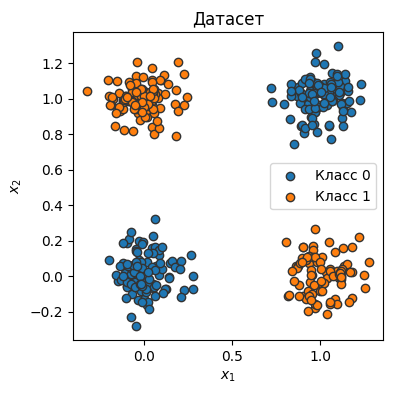

In [ ]:
visualize_samples(train_dataset.data, train_dataset.label)
plt.show()

In [ ]:
# Создаем загрузчики данных
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False)

# Получаем первый батч данных
data_inputs, data_labels = next(iter(train_loader))

# Данные на выходе имеют размерность [batch_size, d_1, ..., d_N], где d_1, ..., d_N
# соответствуют размерностям одной точки данных из вашего набора
print("Признаки", data_inputs.shape, "\n", data_inputs)
print("Лейблы", data_labels.shape, "\n", data_labels)

Присзнаки torch.Size([8, 2]) 
 tensor([[ 0.0045,  0.9526],
        [-0.0814,  1.0952],
        [-0.0156,  1.0165],
        [ 0.8376,  0.0270],
        [ 0.8647,  0.0565],
        [ 1.0061, -0.0242],
        [ 0.9648, -0.0508],
        [ 0.9148,  0.9404]])
Лейблы torch.Size([8]) 
 tensor([1, 1, 1, 1, 1, 1, 1, 0])


In [ ]:
class Net(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.tanh = nn.Tanh()

    def forward(self, input):
        output = self.linear(input)
        output = self.tanh(output)
        return output

In [ ]:
# Инициализация модели для XOR (2D -> 1D)
model = Net(in_dim=2, out_dim=1).to(device)
# MSE лосс для регрессии
criterion = nn.MSELoss(reduction='mean')
# SGD с L2-регуляризацией
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)

In [ ]:
num_epochs = 20

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss = train_epoch(epoch)  # Обучение модели
    test_loss = test_epoch(epoch)    # Оценка на тестовых данных

    # Сохранение метрик
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # Вывод статистики
    epoch_time = time.time() - start_time
    print(f'Эпоха {epoch + 1} / {num_epochs} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Test Loss: {test_loss:.4f} | '
          f'Время: {epoch_time:.2f}s')

Эпоха 1 / 20 | Train Loss: 0.4251 | Test Loss: 0.3047 | Время: 0.30s
Эпоха 2 / 20 | Train Loss: 0.2957 | Test Loss: 0.2640 | Время: 0.06s
Эпоха 3 / 20 | Train Loss: 0.2756 | Test Loss: 0.2551 | Время: 0.05s
Эпоха 4 / 20 | Train Loss: 0.2702 | Test Loss: 0.2519 | Время: 0.05s
Эпоха 5 / 20 | Train Loss: 0.2677 | Test Loss: 0.2499 | Время: 0.05s
Эпоха 6 / 20 | Train Loss: 0.2662 | Test Loss: 0.2485 | Время: 0.05s
Эпоха 7 / 20 | Train Loss: 0.2649 | Test Loss: 0.2472 | Время: 0.05s
Эпоха 8 / 20 | Train Loss: 0.2639 | Test Loss: 0.2462 | Время: 0.05s
Эпоха 9 / 20 | Train Loss: 0.2628 | Test Loss: 0.2453 | Время: 0.06s
Эпоха 10 / 20 | Train Loss: 0.2617 | Test Loss: 0.2443 | Время: 0.05s
Эпоха 11 / 20 | Train Loss: 0.2609 | Test Loss: 0.2436 | Время: 0.06s
Эпоха 12 / 20 | Train Loss: 0.2600 | Test Loss: 0.2428 | Время: 0.05s
Эпоха 13 / 20 | Train Loss: 0.2594 | Test Loss: 0.2426 | Время: 0.07s
Эпоха 14 / 20 | Train Loss: 0.2585 | Test Loss: 0.2419 | Время: 0.06s
Эпоха 15 / 20 | Train Loss: 0

In [ ]:
train_loss = {
    'label' : 'Train Loss',
    'x' : np.arange(len(train_losses)),
    'history' : train_losses
}

test_loss = {
    'label' : 'Test Loss',
    'x' : np.arange(len(test_losses)),
    'history' : test_losses
}

In [ ]:
import itertools

def make_plots_loss(methods, title='', x_label='Номер итерации', y_label='Loss'):
    fig = plt.figure(figsize=(8, 6))
    plt.title(title, fontsize=22)
    plt.gca().set_facecolor('#519dfc')
    plt.gca().patch.set_alpha(0.15)

    marker = itertools.cycle(('o', 's', '*', '^', 'h'))
    color = itertools.cycle(('crimson', 'forestgreen', 'darkorange', 'navy', 'darkmagenta'))

    for method in methods:
        plt.semilogy(method['x'], method['history'],
                    linewidth=3, color=next(color), marker=next(marker), markersize=7,
                    markevery=range(0, len(method['history']), int(len(method['history']) / 5)), markeredgecolor = 'black', label = method['label'])

    plt.legend(fontsize=20)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.xlabel(x_label, fontsize=20)
    plt.ylabel(y_label, fontsize=20)

    plt.grid(color='#6d7175', linestyle='--', linewidth=0.7, alpha=0.9)
    plt.show()

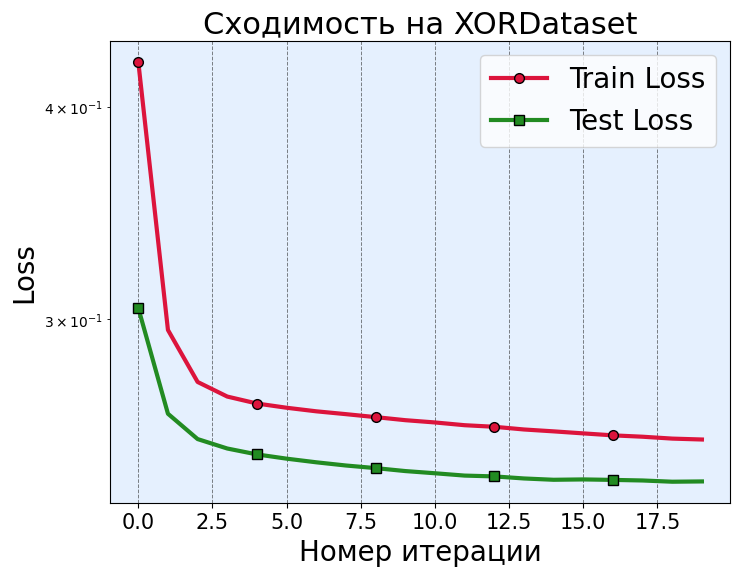

In [ ]:
make_plots_loss([train_loss, test_loss], title='Сходимость на XORDataset')

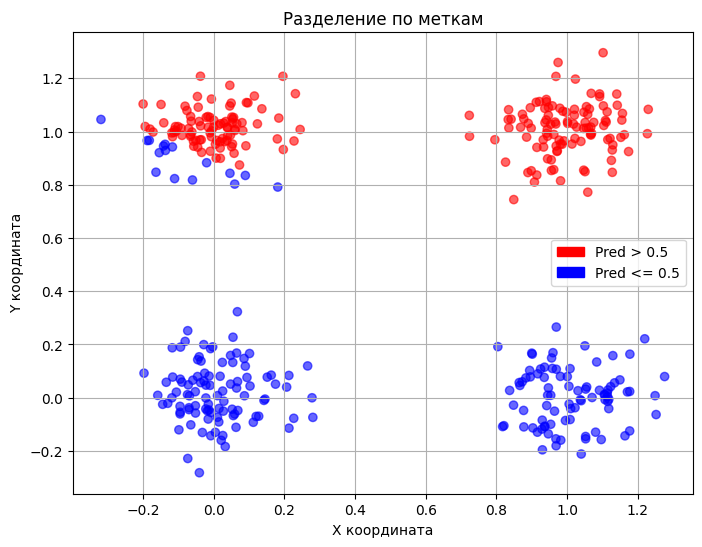

In [ ]:
import matplotlib.patches as mpatches

coords = train_dataset.data
preds = model(train_dataset.data.to(device)).cpu().detach().numpy()
colors = np.where(preds > 0.5, 'r', 'b')  # красный если > 0.5, иначе синий

# Рисуем scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=colors.flatten(), alpha=0.6)
plt.title('Разделение по меткам')
plt.xlabel('X координата')
plt.ylabel('Y координата')
plt.grid(True)

# Добавим цветовую легенду
red_patch = mpatches.Patch(color='red', label='Pred > 0.5')
blue_patch = mpatches.Patch(color='blue', label='Pred <= 0.5')
plt.legend(handles=[red_patch, blue_patch])

plt.show()